# Problem 3: Laminar Flow Above an Oscillating Plate
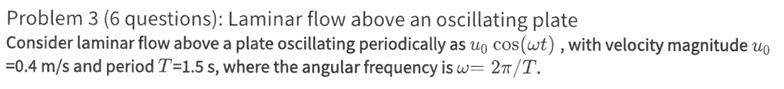

In [1]:
import numpy as np
import sympy as sp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from matplotlib import animation
from scipy.integrate import quad

In [2]:
u_0 = 0.4                   # Plate velocity amplitude [m/s]
T = 1.5                     # Time [s]
viscosity = 1.3*10**-6      # Kinematic viscosity [m2/s]
rho_water = 1000            # density of water (kg/m^3)

### Question 3.1
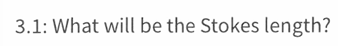

In [12]:
omega = 2 * np.pi / T                   # Angular frequency [rad/s]
delta = np.sqrt(2*viscosity/omega)      # stokes length [m]                 # P7 eq. 2.54 p.21

print(f"Stokes length: {delta:.6f} m")

Stokes length: 0.000788 m


### Question 3.2
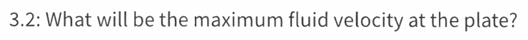

In [4]:
T_array = np.linspace(0, T, 100)
u_max = max(u_0 * np.cos(omega * T_array))  # <-- the max is at t=0 so abs(u_0)

print(f"Maximum velocity in the fluid: {u_max:.4f} m/s")

Maximum velocity in the fluid: 0.4000 m/s


### Question 3.3
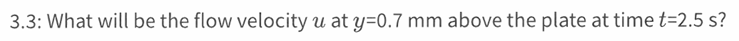
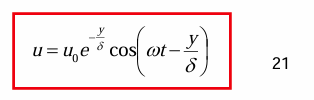

In [5]:
y1 = 0.0007
t1 = 2.5

# Flow Velocity function
u_yt = lambda y, t: u_0 * np.exp(-y/delta) * np.cos(omega*t - y/delta)          # P7 eq. (bottom right corner) p.21

u_at_y1_t1 = u_yt(y1, t1)
print(f"Velocity at y={y1} m and t={t1} s: {u_at_y1_t1:.2f} m/s")

Velocity at y=0.0007 m and t=2.5 s: -0.16 m/s


### Question 3.4
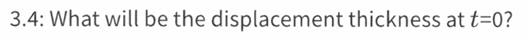
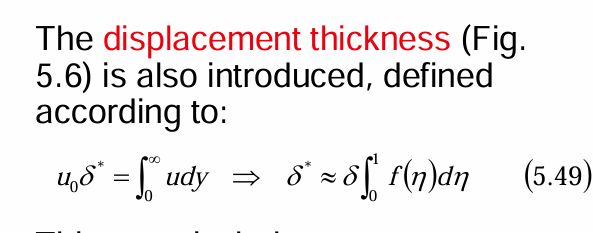

In [10]:
# Displacement thickness at t=0
def integrand(y):
    uyt = u_0 * np.exp(-y/delta) * np.cos(omega*0 - y/delta)
    return uyt/u_0

# Calculate the displacement thickess
delta_star_num, _ = quad(integrand, 0, np.inf)      # result, estimated error

# Print the result
print(f"Displacement thickness at t=0: {delta_star_num:.6f} m")


Displacement thickness at t=0: 0.000394 m


### Question 3.5
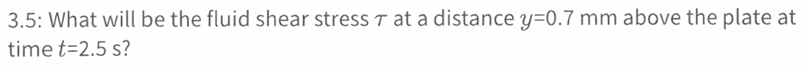

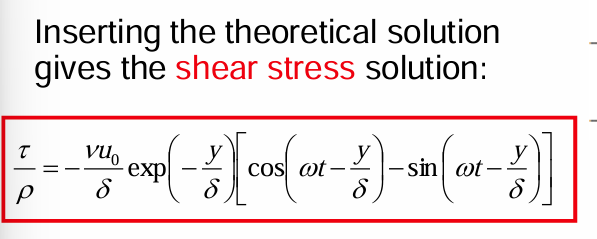

In [7]:
# Shear stress at the wall
shear_stress = lambda y,t: (-viscosity*u_0/delta*np.exp(-y/delta)*(np.cos(omega*t - y/delta) - np.sin(omega*t - y/delta))) * rho_water  # [Pa]   # P7 eq. 2.56 p.21
shear_at_y0_t1 = shear_stress(y1, t1)
print(f"Shear stress at the wall at t={t1} s: {shear_at_y0_t1:.3f} Pa")

Shear stress at the wall at t=2.5 s: 0.225 Pa


### Question 3.5
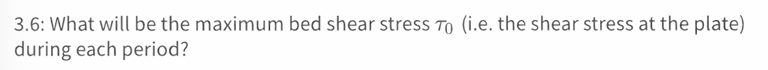

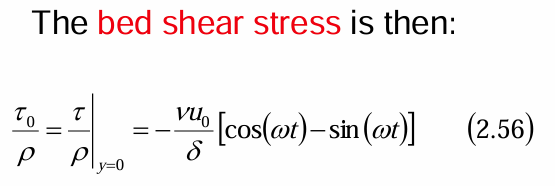

In [8]:
# dynamic visocisty
mu = viscosity * rho_water  # [Pa.s]

# Bed shear stress at the wall
bed_shear_stress = (-viscosity*u_0/delta*(np.cos(omega*t1) - np.sin(omega*t1))) * rho_water  # [Pa]   # P7 eq. 2.56 p.21
#print(f"Bed shear stress at the wall at t={t1} s: {bed_shear_stress:.4f} Pa")

In [9]:
# Bed shear stress at the wall
bed_shear_stress = lambda t: (-viscosity*u_0/delta*(np.cos(omega*t) - np.sin(omega*t))) * rho_water  # [Pa]   # P7 eq. 2.56 p.21

for t in T_array:
    tau_bed = bed_shear_stress(t)

max_bed_shear = max(bed_shear_stress(T_array))
print(f"Maximum bed shear stress at the wall: {max_bed_shear:.4f} Pa")

Maximum bed shear stress at the wall: 0.9334 Pa
